# Import the all Required Labraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

# 1. (1)Load the Dataset

In [2]:
Deliveries_DF = pd.read_csv("D:\OneDrive\Desktop\Practical Exam (Interview)\Deliveries.csv")
Routes_DF = pd.read_csv("D:\OneDrive\Desktop\Practical Exam (Interview)\Routes.csv")

Deliveries_DF

,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5
5,6,Feb,R2,Delhi,3,3
6,7,Feb,R3,Delhi,5,10
7,8,Feb,R4,Chennai,6,7
8,9,Mar,R1,Delhi,2,8
9,10,Mar,R2,Mumbai,3,5


In [3]:
Routes_DF

,route_id,route,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard


# 1. (2)Remove the Duplicates

In [4]:
print(f"The number of rows Before Delete the Duplicates : {len(Deliveries_DF)}")
Deliveries_DF = Deliveries_DF.drop_duplicates()
print(f"The number of rows After Delete the Duplicates : {len(Deliveries_DF)}")

The number of rows Before Delete the Duplicates : 13
The number of rows After Delete the Duplicates : 12


# 1. (3)Merge the Delivery Dataset to Routes

In [5]:
Merged = Deliveries_DF.merge(Routes_DF , on = "route_id" , how = "left")
Merged

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


# 2. (1) Calculate Delay Days

In [6]:
Merged["Delay_Days"] = (Merged['actual_days'] - Merged['promised_days']).clip(lower = 0)
Merged["Delay_Days"]

0     0
1     1
2     3
3     4
4     3
5     0
6     5
7     1
8     6
9     2
10    0
11    9
Name: Delay_Days, dtype: int64

In [7]:
Merged

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,Delay_Days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3
5,6,Feb,R2,Delhi,3,3,City Dash,Express,0
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard,5
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard,1
8,9,Mar,R1,Delhi,2,8,Metro Link,Express,6
9,10,Mar,R2,Mumbai,3,5,City Dash,Express,2


# 2. (2)Group Summary By Service Type

In [8]:
Merged["Delay_Days_for_GroupBy"] = (Merged['actual_days'] > Merged['promised_days']).astype(int)
Merged["Delay_Days_for_GroupBy"].reset_index()

,index,Delay_Days_for_GroupBy
0,0,0
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,1
7,7,1
8,8,1
9,9,1


In [9]:
Group_Summary = Merged.groupby("service_type").agg(Total_Delay_Days = ("Delay_Days" , "sum")  ,
                                                   Delay_Days = ("Delay_Days_for_GroupBy" , "sum"))


Incidence_Rate = (Group_Summary["Delay_Days"] / Group_Summary["Total_Delay_Days"]) * 100
Incidence_Rate = Incidence_Rate.round()
Incidence_Rate

service_type
Express     33.0
Standard    23.0
dtype: float64

# 2. (3)Gretest summed Delay Days

In [10]:
Highest_Delay_Route = Merged.groupby("route")["Delay_Days"].sum().reset_index().sort_values("Delay_Days" , ascending = False)
print(f"The Gretest Daley Days Route is : {Highest_Delay_Route["route"].iloc[0]}")
print(f"The Total Number of Daley Days is : {Highest_Delay_Route["Delay_Days"].iloc[0]}")

The Gretest Daley Days Route is : Rural Feeder
The Total Number of Daley Days is : 14


In [11]:
Share_Rate = (Highest_Delay_Route["Delay_Days"].iloc[0] / Merged["Delay_Days"].sum()) * 100
Share_Rate = Share_Rate.round(2)
Share_Rate

np.float64(41.18)

# Monthy Line Chart

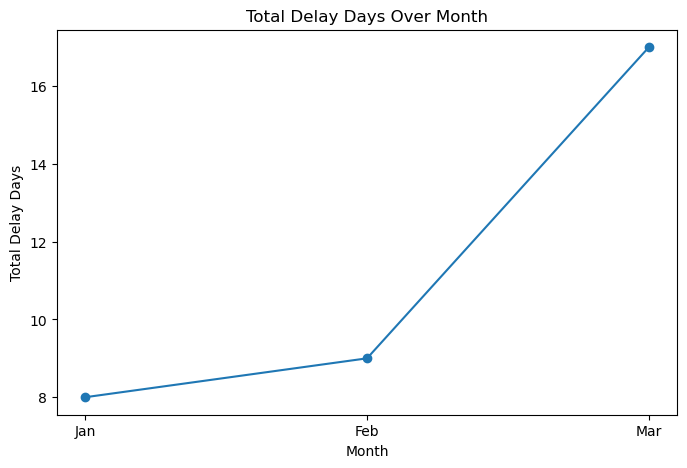

In [12]:
Month_Order = ["Jan", "Feb", "Mar"]

Monthly_Chart = Merged.groupby("month")["Delay_Days"].sum().reindex(["Jan" , "Feb" , "Mar"])


plt.figure(figsize=(8, 5))

plt.plot(Monthly_Chart.index , Monthly_Chart.values , marker = "o")

plt.title("Total Delay Days Over Month")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")

plt.savefig("output/Monthly_Chart.png" , dpi = 150)

plt.show()

In [ ]:
os.makedirs("output" , exist_ok = True)

Merged.to_csv("output/clean_data.csv" , index = False)
Group_Summary.to_csv("output/Group_Summary.csv" , index = False)